In [11]:
# use gemini build dataset
import os
import numpy as np
import numpy_financial as npf
import pandas as pd
import math
import csv
from datetime import datetime

from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory
from langchain_google_genai import ChatGoogleGenerativeAI

def gemini_response(model, instruction, count):
    scores = []

    for i in range(count):

        try:
            result = model.invoke(instruction)
            scores.append(int(result.content))
        except:
            pass

    if len(scores) == 0:
        score = 0
    else:
        score = sum(scores) / len(scores)

    return [date_obj.strftime('%Y%m%d'), score]  # [時間, 分數]



if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = os.getenv('GEMINI_API_KEY')

regenerate_count = 10
# prompt_mutate_count = 100

start_time = datetime(2023, 1, 1)
end_time = datetime(2023, 12, 31)
irr_ = 0

stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]
stock_names = ["台泥", "長榮鋼", "群光", "興富發", "華南金", "統一超", "信邦", "欣銓", "祥碩", "鈦昇"]
# stock_ids = ["2912", "3023", "3264", "5269", "8027"]


p_mutate = '深入的公司創新分析及其對預期市場影響的評估，表明股價持續上漲，反映了投資者對公司令人振奮的長期增長前景的樂觀情緒。'

llm = ChatGoogleGenerativeAI(
    model="gemini-pro",
    temperature=1,
    safety_settings={
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    })


id = []
text = []
response = []

for idx, stock_id in enumerate(stock_ids):
    print(f'執行{stock_id}, {idx}')
    folder_path = "stock_news/" + stock_id + "/" + stock_id + "_news/"
    files = os.listdir(folder_path)
    sorted_files = sorted(files)

    # 載入買進價格
    df = pd.read_csv("price_history/" + stock_id + ".csv", dtype=str)
    price_np = df.to_numpy()
    prices = price_np.tolist()  # [時間,價格]

    signal_2 = []

    for price in prices:
        # 檢查日期是否在參考日期之後
        try:
            date_obj = datetime.strptime(price[0], '%Y%m%d')
        except:
            continue

        if not (start_time <= date_obj <= end_time):
            continue
        

        for j, file_name in enumerate(sorted_files):
            if file_name == price[0]:
                with open(folder_path + file_name, encoding='utf-8') as f:
                    
                    general_prompt = f'請依據{p_mutate}對以下關於{stock_names[idx]}的報導，給這篇文章打一個分數，分數介於-100～100之間，-100是負向，100是最好，0則是無法判斷'

                    news = f.read()
                    # print(news)
                    prompt = general_prompt + "\n" + news
                    # gemini的回應，回傳帶有買入訊號的list
                    signal = gemini_response(llm, prompt, regenerate_count)
                    # print(price)
                    # print(signal)
                    sig = signal[1]

                    id.append(price[0])
                    text.append(news)
                    response.append(sig)
                    # [id(日期), text(新聞), llm回應]
                    # signal_2.append([price[0], news, sig])
                break
            
        # print(id)      
        # print(text)      
        # print(response)        

# todo 用pd寫入CSV文件
df = pd.DataFrame({'id': id, 'text': text, 'response': response})
# with open('dataset/id.csv', 'w', newline='', encoding='utf-8') as csvfile:
#     csv_writer = csv.writer(csvfile)
#     csv_writer.writerow(id)

# with open('dataset/text.csv', 'w', newline='', encoding='utf-8') as csvfile:
#     csv_writer = csv.writer(csvfile)
#     csv_writer.writerow(text)

# with open('dataset/response.csv', 'w', newline='', encoding='utf-8') as csvfile:
#     csv_writer = csv.writer(csvfile)
#     csv_writer.writerow(response)

執行1101, 0
執行2211, 1
執行2385, 2
執行2542, 3
執行2880, 4
執行2912, 5
執行3023, 6
執行3264, 7
執行5269, 8
執行8027, 9


In [26]:
# 標籤,分數
import pandas as pd
from collections import Counter

df = pd.read_csv("dataset/signal.csv")
df['text'].tolist()
df['response'].tolist()

text = []
response = []

# 平衡資料 移除部分標籤
for i in range(-100,100):
    for j in range(len(df['response'].tolist())):
        if df['response'].tolist()[j] == i:
            # print(df['response'].tolist()[j])
            response.append(df['response'].tolist()[j])
            text.append(df['text'].tolist()[j])
            break

response2 = response
# 使用Counter計算每個元素的出現次數
element_counts = Counter(response2)
# 將字典轉換為元組列表，並按值進行排序
sorted_items = sorted(element_counts.items(), key=lambda x: x[0])

# 打印結果
print(sorted_items)

[(-100, 1), (-95, 1), (-94, 1), (-91, 1), (-90, 1), (-88, 1), (-87, 1), (-85, 1), (-83, 1), (-82, 1), (-81, 1), (-80, 1), (-78, 1), (-77, 1), (-75, 1), (-74, 1), (-72, 1), (-71, 1), (-70, 1), (-66, 1), (-65, 1), (-64, 1), (-63, 1), (-62, 1), (-61, 1), (-60, 1), (-59, 1), (-57, 1), (-56, 1), (-55, 1), (-54, 1), (-52, 1), (-51, 1), (-50, 1), (-49, 1), (-45, 1), (-44, 1), (-43, 1), (-42, 1), (-41, 1), (-40, 1), (-39, 1), (-38, 1), (-37, 1), (-36, 1), (-35, 1), (-34, 1), (-33, 1), (-32, 1), (-31, 1), (-30, 1), (-29, 1), (-28, 1), (-27, 1), (-26, 1), (-25, 1), (-24, 1), (-23, 1), (-22, 1), (-21, 1), (-20, 1), (-19, 1), (-18, 1), (-17, 1), (-16, 1), (-15, 1), (-14, 1), (-13, 1), (-12, 1), (-11, 1), (-10, 1), (-9, 1), (-8, 1), (-7, 1), (-6, 1), (-5, 1), (-4, 1), (-3, 1), (-2, 1), (-1, 1), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (22, 1), (26, 1), (27, 1), (

In [18]:
# 改成5分標籤
import pandas as pd
import datasets
from datasets import Dataset, DatasetDict

df = pd.read_csv("dataset/signal.csv")
text = df['text'].tolist()
response = df['response'].tolist()

for i in range(len(response)):
    res_int = int(response[i])
    if res_int > 50:
        response[i] = "非常好"
    elif res_int > 0:
        response[i] = "好"
    elif res_int < -50:
        response[i] = "非常不好"
    elif res_int < -50:
        response[i] = "不好"
    else:
        response[i] = "一般"
    
print(response)
#平衡資料 移除部分標籤
for i in range(30):
    idx = response.index("一般")
    text.pop(idx)
    response.pop(idx)


['一般', '一般', '一般', '一般', '一般', '一般', '一般', '非常不好', '一般', '一般', '非常不好', '非常不好', '非常不好', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '非常不好', '一般', '非常不好', '一般', '非常好', '一般', '非常不好', '好', '一般', '非常不好', '非常不好', '一般', '非常好', '一般', '一般', '非常不好', '非常不好', '一般', '一般', '好', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '好', '好', '一般', '一般', '非常不好', '一般', '好', '非常不好', '一般', '一般', '一般', '一般', '非常不好', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '非常不好', '非常不好', '非常不好', '非常不好', '一般', '一般', '一般', '一般', '一般', '非常不好', '非常不好', '一般', '非常不好', '非常不好', '一般', '一般', '一般', '一般', '一般', '好', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '非常不好', '非常不好', '非常不好', '一般', '非常不好', '一般', '一般', '一般', '一般', '好', '一般', '一般', '非常不好', '一般', '一般', '一般', '一般', '一般', '一般', '非常不好', '一般', '非常不好', '一般', '一般', '非常不好', '非常不好', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '一般', '好', '非常不好', '一般', '一般', '非常不好', '一般', '一般', '非常不好', '非常好', '非常好', '一般', '非常不好', '一般', '非常不好', '非常不好', '一般',

In [30]:
# 整理上傳hugginface

# 第一次需要安裝
# %pip install transformers
# %pip install huggingface_hub
# %pip install datasets

import datasets
from datasets import Dataset, DatasetDict

print("檢查這兩個值是否相等")
print(len(response))
print(len(text))

train_val_splt = 0.8
trn_tst_spt = 0.9

n = int(0.8*len(response))
n2 = int(0.9*len(response))


tdf = pd.DataFrame({"text": text[:n], "response": response[:n]})
vdf = pd.DataFrame({"text": text[n:n2], "response": response[n:n2]})
ted = pd.DataFrame({"text": text[n2:], "response": response[n2:]})

tds = Dataset.from_pandas(tdf)
vds = Dataset.from_pandas(vdf)
ted = Dataset.from_pandas(ted)

ds = DatasetDict()

ds['train'] = tds
ds['validation'] = vds
ds['test'] = ted

print(ds)

# 上傳 hugginface
ds.push_to_hub(repo_id="Atomuze/stock_news_score", private=True)

142
142
DatasetDict({
    train: Dataset({
        features: ['text', 'response'],
        num_rows: 113
    })
    validation: Dataset({
        features: ['text', 'response'],
        num_rows: 14
    })
    test: Dataset({
        features: ['text', 'response'],
        num_rows: 15
    })
})


Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]
c:\Users\user\Desktop\LLM-Predict-Stock\.venv\Lib\site-packages\huggingface_hub\file_download.py:148: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--Atomuze--stock_news_score. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/Atomuze/stock_news_score/commit/ff372a11c4e45f8e25f952a9b4a3636a2c184222', commit_message='Upload dataset', commit_description='', oid='ff372a11c4e45f8e25f952a9b4a3636a2c184222', pr_url=None, pr_revision=None, pr_num=None)

In [72]:
def calculate_return(signal, threshold):
    # signal = [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance = 10000000
    init_balance = balance
    
    list_bnh = []
    list_rtn = []

    for item in signal:
        score = float(item[1])
        price = float(item[2])

        # if hold == 0:
        #     if score > 0:
        #         hold += int(balance/price)
        #         balance = 0
        # elif hold > 0:
        #     if score < 0:
        #         balance += price*hold
        #         hold = 0

        if hold == 0:
            if score == 2:
                hold += int(balance/price)
                balance = 0
            elif score == 1:
                hold += int((balance/2)/price)
                balance = int(balance/2)
        elif hold > 0:
            if score < 0:
                balance += price*hold
                hold = 0
            elif score == 2:
                hold += int(balance/price)
                balance = 0
        # print(f"score: {score}, price: {price}, hold: {hold}, balance: {balance}, total: {balance + hold*price}")

        list_rtn.append((balance + hold*price)/init_balance)
        list_bnh.append(price/float(signal[0][2]))
    
    balance += hold*price
    last_price = float(signal[len(signal) - 1][2])
    bnh = last_price / float(signal[0][2])
    r = balance/init_balance

    plt.title('Return')
    plt.plot(list_rtn, label='strategy', color='red')
    plt.plot(list_bnh, label='buy and hold', color='blue')
    plt.legend()
    plt.show()

    return round(r, 5), round(bnh, 5)

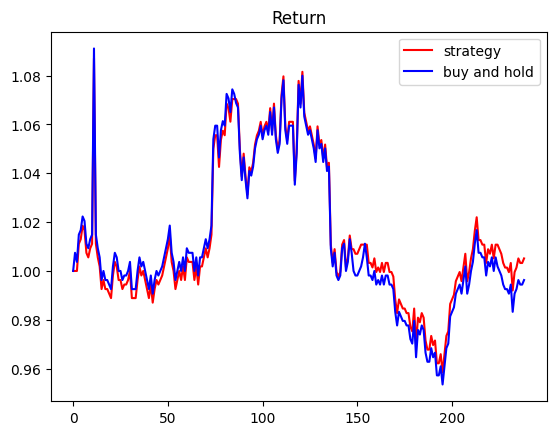

1.00513 0.99628


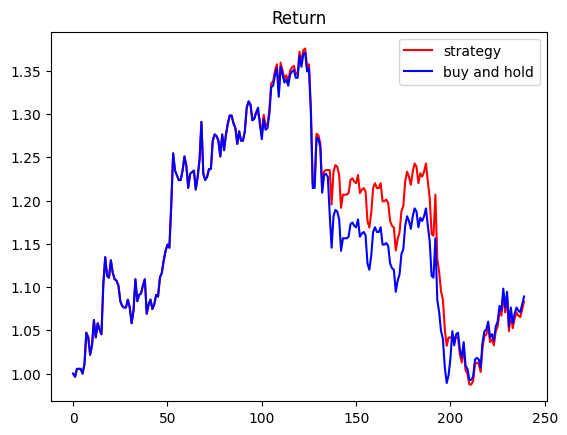

1.08326 1.08909


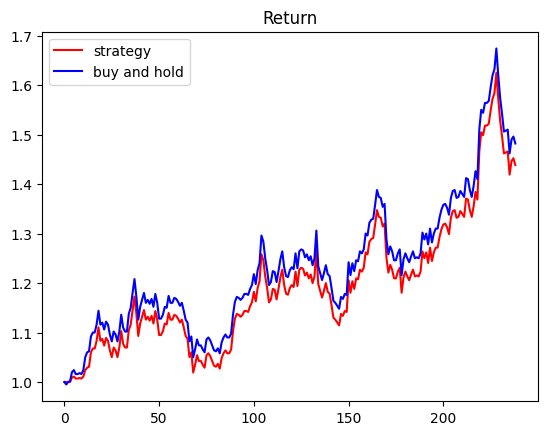

1.43857 1.482


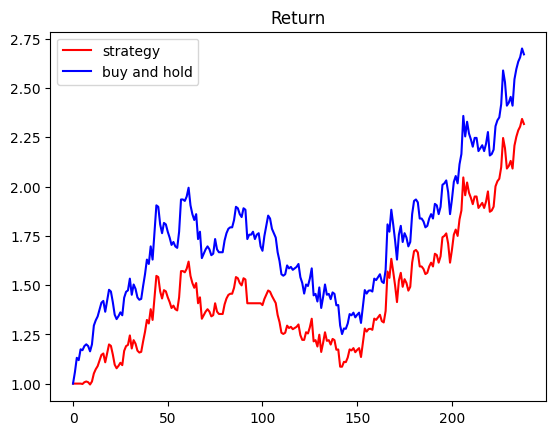

2.31752 2.67113


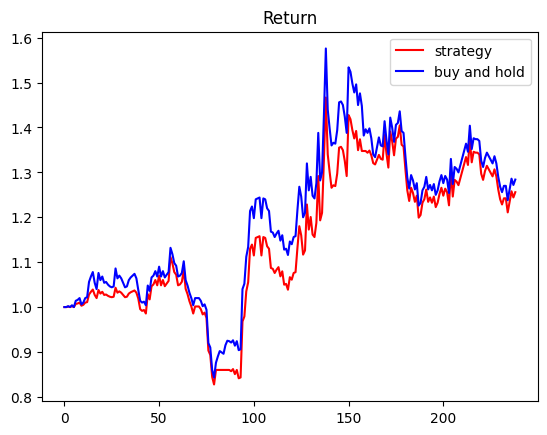

1.25593 1.284
平均報酬率:1.25593，平均總額投入報酬率:1.284


In [73]:
import pandas as pd
import matplotlib.pyplot as plt

rtns = []
bnhs = []

for i in range(5):
    list = pd.read_csv("eval_llama/output1/" + str(i+1) +".csv", header=None, index_col=False, skiprows=1, usecols=[1, 2, 3]).to_numpy().tolist()
    # print(list)

    rtn, bnh = calculate_return(list, 0)
    print(rtn, bnh)


rtns.append(rtn)
bnhs.append(bnh)
print(f'平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{sum(bnhs) / len(bnhs)}')
# raw_data.append(signal_2_np.tolist())

In [2]:
import ollama

ollama.embeddings(
  model='mxbai-embed-large',
  prompt='Llamas are members of the camelid family',
)

{'embedding': [-0.5236849188804626,
  -0.26121288537979126,
  -0.14445000886917114,
  -0.016575902700424194,
  0.1762562096118927,
  -0.4820021986961365,
  -0.7987318634986877,
  -0.1953413486480713,
  0.37544938921928406,
  0.2608010470867157,
  0.6666195392608643,
  -0.32320061326026917,
  0.11413022130727768,
  0.3939250707626343,
  -0.3515661954879761,
  -0.3349548280239105,
  -0.5676146149635315,
  -0.19100472331047058,
  -0.9453977346420288,
  0.12703834474086761,
  -0.6448055505752563,
  0.9130483865737915,
  -0.4055860638618469,
  -0.3647956848144531,
  -0.23561476171016693,
  0.585121214389801,
  0.4986245036125183,
  0.5503227710723877,
  0.7015033960342407,
  0.5690469145774841,
  0.3037552535533905,
  0.009113937616348267,
  -0.11650454998016357,
  -0.8941529989242554,
  0.3864504098892212,
  0.09601868689060211,
  0.28054800629615784,
  -0.6760269403457642,
  0.10943702608346939,
  -0.08416980504989624,
  0.40332621335983276,
  -0.9171355962753296,
  0.37454259395599365,
 